In [1]:
# --- make src/ importable regardless of working directory -------------------
# Walks up from the current directory (or $AP1_REPO_ROOT) to find the repo root.
import os, sys, pathlib

def _ap1_repo_root():
    start = os.environ.get("AP1_REPO_ROOT") or pathlib.Path.cwd()
    start = pathlib.Path(start).resolve()
    for cand in [start, *start.parents]:
        if (cand / "src").is_dir() and (cand / "analysis").is_dir():
            return cand
    raise FileNotFoundError(
        "Could not locate the AP1-network-ODEmodelingAnalysis root from "
        f"{start}. Set it explicitly before this cell, e.g.\n"
        "    os.environ['AP1_REPO_ROOT'] = '/path/to/AP1-network-ODEmodelingAnalysis'"
    )

_src = str(_ap1_repo_root() / "src")
if _src not in sys.path:
    sys.path.insert(0, _src)
# ---------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

import warnings
import importlib 
import plsda_module

import plot_ap1
import plotly.express as px
import io
import matplotlib as mpl
from scipy.stats import randint, uniform
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [2]:
plt.rcParams['xtick.labelsize'] = 22 # or whatever size you want
plt.rcParams['ytick.labelsize'] = 22 # or whatever size you want

# Set global font size for labels, titles and legends
plt.rcParams['axes.labelsize'] = 20# or whatever size you want
plt.rcParams['axes.titlesize'] = 20 # or whatever size you want
plt.rcParams['legend.fontsize'] = 16 # or whatever size you want
#plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True


In [3]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42

mpl.rcParams['svg.fonttype'] = 'none'

In [4]:
folder_path = "/Volumes/FallahiLab/Maize-Data/Data/Yonatan_Degefu/AP1_mechanistic_modelling/processed_simulations/updated_cell_specific_simulations/"
cell = 'LOXIMVI'
version = "V4"

data_file = f"{cell}_cell_specific_parameter_initialcondition_and_steadystates_{version}.csv"
dat = pd.read_csv(os.path.join(folder_path, data_file))


In [5]:
importlib.reload(plsda_module)
from plsda_module import PLSDA

importlib.reload(plot_ap1)
from plot_ap1 import plot_parameter_distributions, plot_2d_scatter,plot_3d_scatter_subplots,plot_3d_density,plot_2d_density_projections



In [6]:
def rename_columns(df):
    new_column_names = {}
    
    def convert_protein_names(text):
        """Convert protein names - order is critical!"""
        # Do longer/more specific names first to avoid partial matches
        text = text.replace('jund', 'JUND')  # Do jund before jun
        text = text.replace('fra2', 'FRA2')  # Do fra2 before fra1
        text = text.replace('fra1', 'FRA1')
        text = text.replace('jun', 'cJUN')   # Do jun after jund
        text = text.replace('fos', 'cFOS')
        return text
    
    for col in df.columns:
        # For basal columns: replace with α (alpha) and add underscore
        if 'basal' in col:
            protein = re.search(r'basal_(\w+)', col).group(1)
            converted_protein = convert_protein_names(protein)
            new_column_names[col] = f"α_{converted_protein}"
        
        # For degradation columns: replace with γ (gamma) and add underscore
        elif 'degradation' in col:
            protein = re.search(r'degradation_(\w+)', col).group(1)
            converted_protein = convert_protein_names(protein)
            new_column_names[col] = f"γ_{converted_protein}"
        
        # For beta columns: replace with β (beta) and add underscore
        elif '.beta' in col:
            interaction = re.search(r'\((.*?)\)\.beta', col).group(1)
            converted_interaction = convert_protein_names(interaction)
            new_column_names[col] = f"β_{converted_interaction}"
        
        # Keep any other columns as is (like 'interest_class')
        else:
            new_column_names[col] = col
    
    return df.rename(columns=new_column_names)

### Figure 5 (B-C)Modeling separation between monostable and bistable states
##### Question: What features in our parameter space separate monostable and bistable states?

In [7]:
dat_1 = dat.copy()
cols_to_remove = ['init_cond_index', 'state', 'fos', 'jun', 'fra1', 'fra2', 'jund','fos_ss','jun_ss','fra1_ss','fra2_ss','jund_ss']
dat_1.drop(cols_to_remove, axis=1, inplace=True)

# drop duplicate param_index
dat_1.drop_duplicates(subset='param_index', inplace=True)

# drop param_index
dat_1.drop('param_index', axis=1, inplace=True)

dat_1

interest_states = ['bi_stable']

dat_1['interest_class'] = np.where(dat_1['unique_steady_states'].isin(interest_states), 1, 0)

# drop the unique_steady_states column
dat_1.drop('unique_steady_states', axis=1, inplace=True)
dat_1

,(basal_fos).v,(basal_jun).v,(basal_fra1).v,(basal_fra2).v,(basal_jund).v,(jun_by_junjun).beta,(jun_by_junfos).beta,(fra1_by_junfra1).beta,(fra1_by_jundfos).beta,(fra2_by_junfra2).beta,(degradation_fos).k1,(degradation_jun).k1,(degradation_fra1).k1,(degradation_fra2).k1,(degradation_jund).k1,interest_class
0,3.51348,6.23938,2.75645,1.17920,5.03680,20.58021,5.81476,78.26636,21.73407,17.17804,0.53332,0.73908,0.30491,0.10016,0.08571,0
150,4.83183,5.65293,0.17113,2.54778,7.01086,58.12772,31.97274,37.20289,102.96200,35.56151,1.53200,0.49401,0.31378,0.11460,0.13307,0
300,0.69610,7.51703,0.17390,0.66903,2.47411,8.79305,169.28631,20.96384,143.84768,2.97708,0.91342,0.76951,0.33246,0.08788,0.06786,0
450,0.72296,6.10969,2.91160,1.25732,5.29329,28.86403,37.24679,53.37406,20.63374,32.33980,0.51991,0.52255,0.54039,0.12717,0.14071,0
600,8.60226,6.19385,0.17837,0.44547,4.28368,3.06599,4.38193,121.09712,47.92727,6.25562,0.93905,0.57594,0.54014,0.09317,0.07512,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192737,2.37300,6.35660,0.17751,1.83279,2.32691,192.29424,3.42321,128.57895,110.00358,26.59985,0.77317,1.15439,0.46146,0.20406,0.11004,0
192887,1.18747,7.88670,0.14613,0.36399,4.30143,18.62674,102.69864,73.89681,2.36649,42.23103,0.78702,0.85766,0.30010,0.11151,0.16108,0
192937,1.02638,6.21016,3.21132,2.35344,6.45143,67.53010,3.29546,32.27748,77.10979,44.00157,1.02830,1.11156,0.31652,0.11765,0.13490,0
193087,7.29294,0.14510,0.14453,1.54536,7.27952,21.59967,139.56446,10.31931,66.98887,4.13817,0.84657,0.54762,0.68252,0.30267,0.10912,0


In [8]:

# Apply the renaming to your existing subset_data
# This will create a new dataframe with renamed columns, preserving all your data
renamed_df = rename_columns(dat_1.copy())

In [10]:
renamed_df

,α_cFOS,α_cJUN,α_FRA1,α_FRA2,α_JUND,β_cJUN_by_cJUNcJUN,β_cJUN_by_cJUNcFOS,β_FRA1_by_cJUNFRA1,β_FRA1_by_JUNDcFOS,β_FRA2_by_cJUNFRA2,γ_cFOS,γ_cJUN,γ_FRA1,γ_FRA2,γ_JUND,interest_class
0,3.51348,6.23938,2.75645,1.17920,5.03680,20.58021,5.81476,78.26636,21.73407,17.17804,0.53332,0.73908,0.30491,0.10016,0.08571,0
150,4.83183,5.65293,0.17113,2.54778,7.01086,58.12772,31.97274,37.20289,102.96200,35.56151,1.53200,0.49401,0.31378,0.11460,0.13307,0
300,0.69610,7.51703,0.17390,0.66903,2.47411,8.79305,169.28631,20.96384,143.84768,2.97708,0.91342,0.76951,0.33246,0.08788,0.06786,0
450,0.72296,6.10969,2.91160,1.25732,5.29329,28.86403,37.24679,53.37406,20.63374,32.33980,0.51991,0.52255,0.54039,0.12717,0.14071,0
600,8.60226,6.19385,0.17837,0.44547,4.28368,3.06599,4.38193,121.09712,47.92727,6.25562,0.93905,0.57594,0.54014,0.09317,0.07512,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192737,2.37300,6.35660,0.17751,1.83279,2.32691,192.29424,3.42321,128.57895,110.00358,26.59985,0.77317,1.15439,0.46146,0.20406,0.11004,0
192887,1.18747,7.88670,0.14613,0.36399,4.30143,18.62674,102.69864,73.89681,2.36649,42.23103,0.78702,0.85766,0.30010,0.11151,0.16108,0
192937,1.02638,6.21016,3.21132,2.35344,6.45143,67.53010,3.29546,32.27748,77.10979,44.00157,1.02830,1.11156,0.31652,0.11765,0.13490,0
193087,7.29294,0.14510,0.14453,1.54536,7.27952,21.59967,139.56446,10.31931,66.98887,4.13817,0.84657,0.54762,0.68252,0.30267,0.10912,0


/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: 

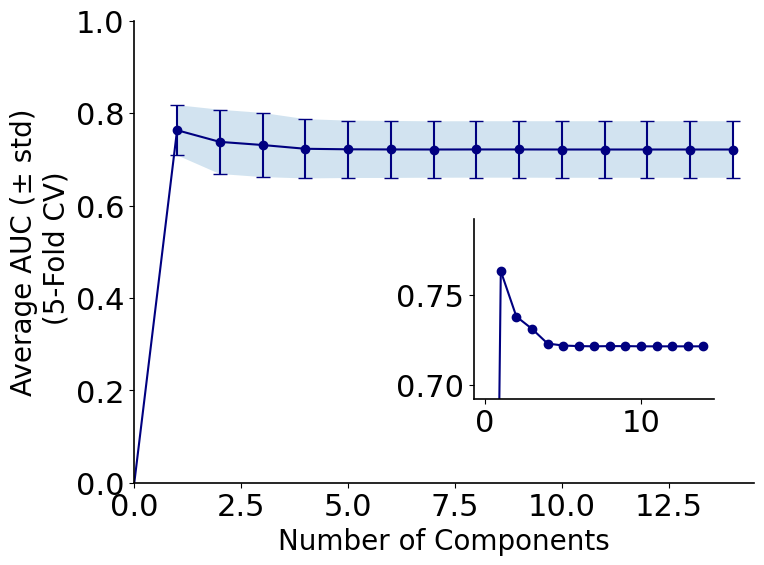

Maximum AUC at components: 1
Diminishing returns at components: 1
Maximum mean AUC: 0.763 ± 0.054
AUC at diminishing returns: 0.763 ± 0.054
Recommended number of components: 1
Optimal number of components: 1
Component 1:
Cumulative Y variance: 29.53%
Incremental Y variance: 29.53%
Component 2:
Cumulative Y variance: 32.50%
Incremental Y variance: 2.97%


In [17]:
X = renamed_df.drop(columns = ['interest_class'])
y = renamed_df['interest_class']

# keep one hot encoding as False
plsda = PLSDA(n_components=None, cv_folds=5, one_hot_encode=False, downsample_ratio= 3)

# Determine the optimal number of components
optimal_components, mean_scores = plsda.find_optimal_components(X, y, max_components=14,save_plot=False)
print(f'Optimal number of components: {optimal_components}')

# Fit and transform the data using the optimal number of components
plsda.n_components = 2
X_pls, x_var,y_var, y_encoded, X_downsampled, y_balanced = plsda.fit_transform(X, y)

class_descriptions = {0: 'mono_stable', 1: 'bi_stable'}
# plot_scores = plsda.plot_scores_with_density(X_pls, x_var,y_var, y_encoded, lv1 = 0, lv2 = 1, class_descriptions=class_descriptions, colors = ['#BCB8B1','#07BEB8'],
#                   alpha_values = [0.7, 1],line_colors = ['w','k'], save_plot=True)


In [ ]:
# Perform cross-validation and plot ROC curve

# y_scores, y_encoded = plsda.cross_validation(X, y)
# #plsda.plot_roc(y_scores, y_encoded)
# plsda.plot_mean_roc(X, y, save_plot=False)
# plsda.plot_mean_roc(X, y, save_plot=False)


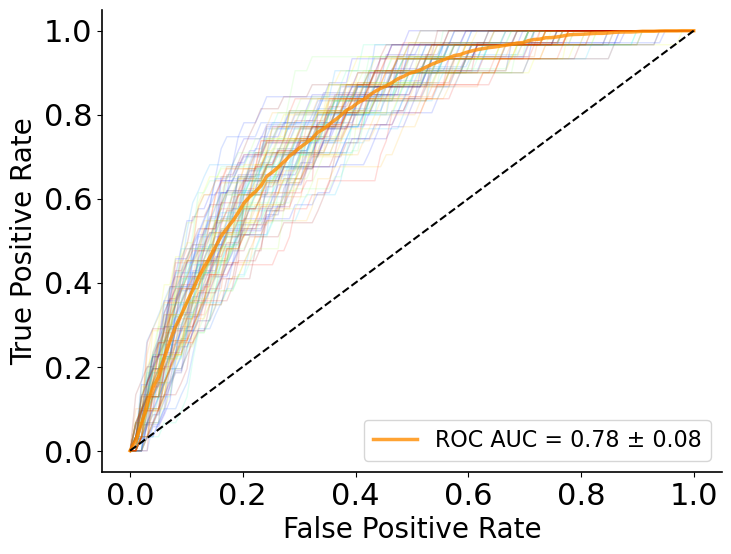

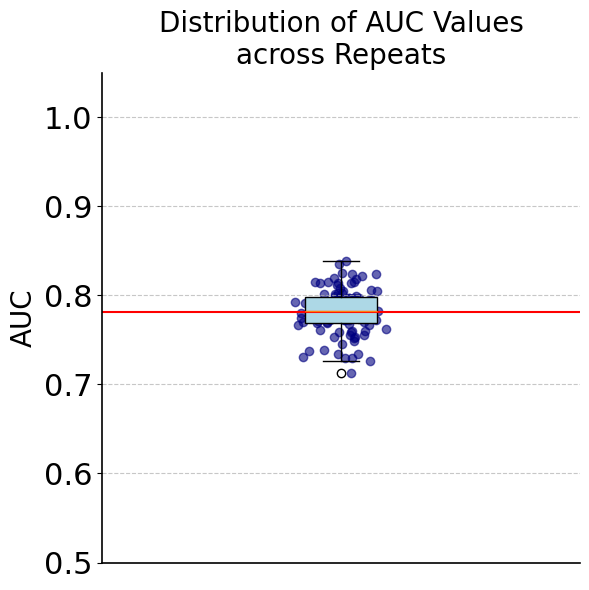

Repeated CV Results (100 repeats):
Mean AUC: 0.782 ± 0.026
Range: [0.713, 0.839]
Repeated cross-validation AUC: 0.782 ± 0.026


In [ ]:
mean_auc, std_auc = plsda.repeated_cv_with_visualization(
    X, y, n_repeats=1000, save_plot=True, show_individual_curves=True
)
print(f"Repeated cross-validation AUC: {mean_auc:.3f} ± {std_auc:.3f}")

In [ ]:
# vip_scores = plsda.compute_vip()
# signed_vip_scores, feature_names = plsda.compute_signed_vip(X,y,X.columns)
# # save figure as pdf

# plsda.plot_signed_vip(signed_vip_scores, feature_names, save_plot=False, colors=['#BCB8B1','#07BEB8'])


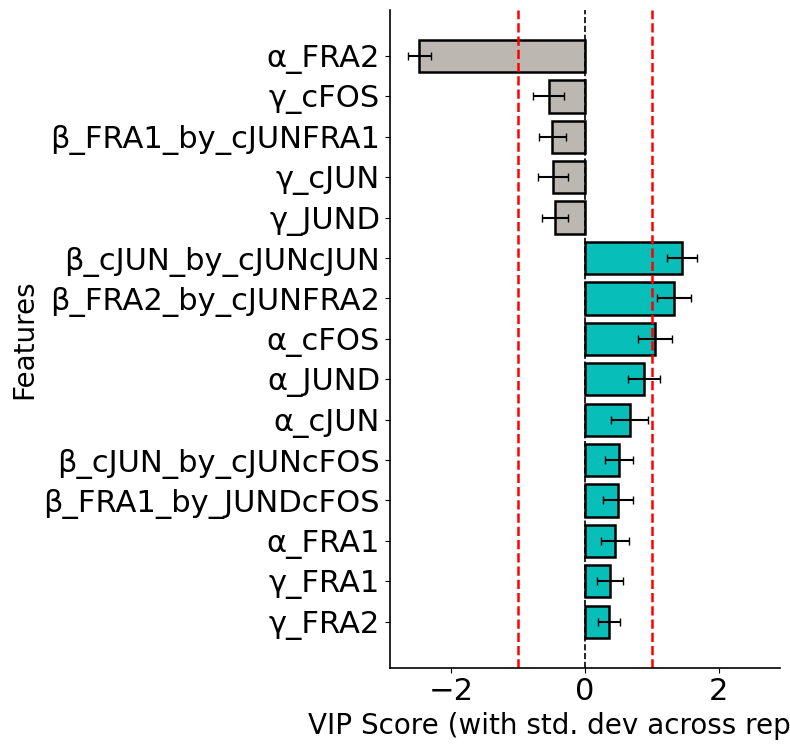

In [ ]:
mean_vips, std_vips, feature_names = plsda.plot_repeated_vip(
    X, y, n_repeats=1000, save_plot=True, colors=['#BCB8B1','#07BEB8']
)

In [ ]:
# extracting the downsampled data
# Assuming X_downsampled and y_balanced are numpy arrays
if isinstance(X_downsampled, np.ndarray) and isinstance(y_balanced, np.ndarray):
    # Create a DataFrame from X_downsampled
    feature_columns = dat_1.drop(columns=['interest_class']).columns
    downsampled_df = pd.DataFrame(X_downsampled, columns=feature_columns)
    
    # Add the y_balanced as a new column
    downsampled_df['interest_class'] = y_balanced

# If X_downsampled and y_balanced are already pandas DataFrame/Series
elif isinstance(X_downsampled, pd.DataFrame) and isinstance(y_balanced, (pd.Series, pd.DataFrame)):
    # Ensure column names match dat_1
    X_downsampled.columns = dat_1.drop(columns=['interest_class']).columns
    
    # Concatenate
    downsampled_df = pd.concat([X_downsampled, y_balanced.rename('interest_class')], axis=1)

# Ensure the column order matches dat_1
downsampled_df = downsampled_df[dat_1.columns]
# rename interest_class column to 'bi_stable' if interest_class is 1
downsampled_df['interest_class'] = downsampled_df['interest_class'].map({0: 'mono_stable', 1: 'bi_stable'})

dat_1_copy = dat_1.copy()
# Update the interest_class column
dat_1_copy['interest_class'] = dat_1_copy['interest_class'].map({0: 'mono_stable', 1: 'bi_stable'})


In [21]:
# if interest_class is 1, then rename the interest_class column to 'bi_stable' else 'mono_stable'
renamed_df['interest_class'] = renamed_df['interest_class'].map({1: 'bi_stable', 0: 'mono_stable'})


In [22]:
renamed_df

,α_cFOS,α_cJUN,α_FRA1,α_FRA2,α_JUND,β_cJUN_by_cJUNcJUN,β_cJUN_by_cJUNcFOS,β_FRA1_by_cJUNFRA1,β_FRA1_by_JUNDcFOS,β_FRA2_by_cJUNFRA2,γ_cFOS,γ_cJUN,γ_FRA1,γ_FRA2,γ_JUND,interest_class
0,3.51348,6.23938,2.75645,1.17920,5.03680,20.58021,5.81476,78.26636,21.73407,17.17804,0.53332,0.73908,0.30491,0.10016,0.08571,mono_stable
150,4.83183,5.65293,0.17113,2.54778,7.01086,58.12772,31.97274,37.20289,102.96200,35.56151,1.53200,0.49401,0.31378,0.11460,0.13307,mono_stable
300,0.69610,7.51703,0.17390,0.66903,2.47411,8.79305,169.28631,20.96384,143.84768,2.97708,0.91342,0.76951,0.33246,0.08788,0.06786,mono_stable
450,0.72296,6.10969,2.91160,1.25732,5.29329,28.86403,37.24679,53.37406,20.63374,32.33980,0.51991,0.52255,0.54039,0.12717,0.14071,mono_stable
600,8.60226,6.19385,0.17837,0.44547,4.28368,3.06599,4.38193,121.09712,47.92727,6.25562,0.93905,0.57594,0.54014,0.09317,0.07512,mono_stable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192737,2.37300,6.35660,0.17751,1.83279,2.32691,192.29424,3.42321,128.57895,110.00358,26.59985,0.77317,1.15439,0.46146,0.20406,0.11004,mono_stable
192887,1.18747,7.88670,0.14613,0.36399,4.30143,18.62674,102.69864,73.89681,2.36649,42.23103,0.78702,0.85766,0.30010,0.11151,0.16108,mono_stable
192937,1.02638,6.21016,3.21132,2.35344,6.45143,67.53010,3.29546,32.27748,77.10979,44.00157,1.02830,1.11156,0.31652,0.11765,0.13490,mono_stable
193087,7.29294,0.14510,0.14453,1.54536,7.27952,21.59967,139.56446,10.31931,66.98887,4.13817,0.84657,0.54762,0.68252,0.30267,0.10912,mono_stable


In [23]:
importlib.reload(plot_ap1)
from plot_ap1 import plot_parameter_distributions, plot_2d_scatter,plot_3d_scatter_subplots,plot_3d_density,plot_2d_density_projections


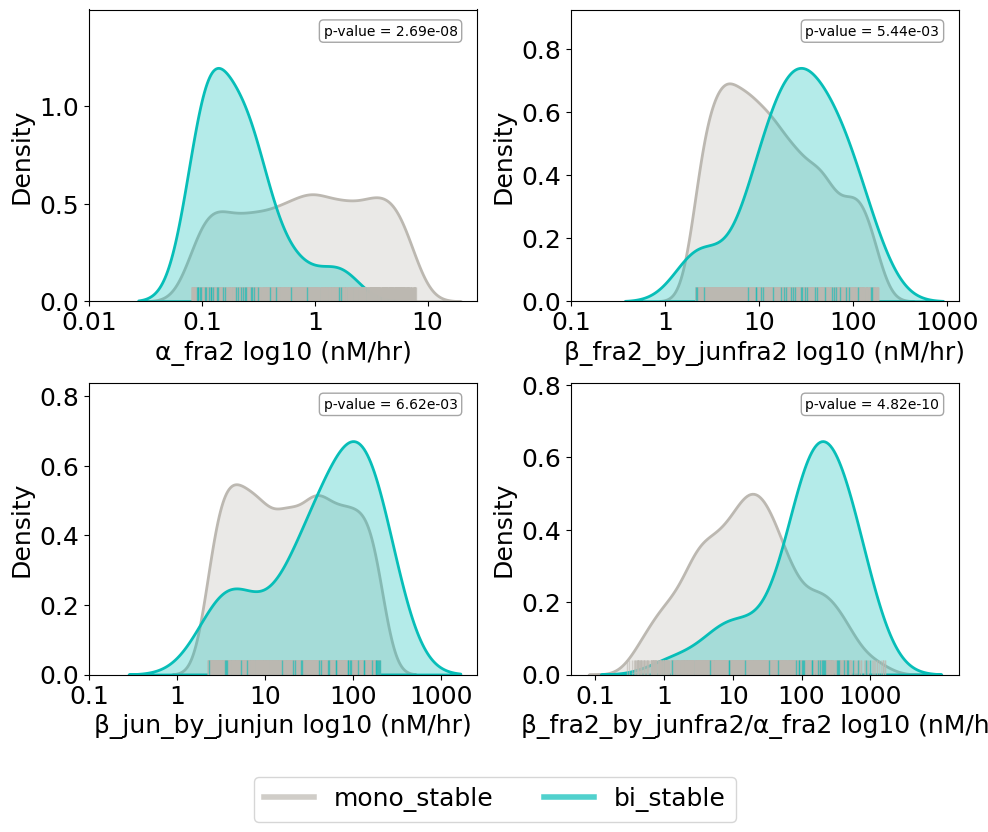

In [37]:
# plot distribution of fra2 for the high and low fra2 states
par_names = ['α_fra2', 'β_fra2_by_junfra2', 'β_jun_by_junjun', 'β_fra2_by_junfra2/α_fra2']
fig = plot_ap1.plot_parameter_distributions(renamed_df, par_names, 'interest_class', 
                                      color_palette={'mono_stable': '#BCB8B1', 'bi_stable': '#07BEB8'}, 
                                      ncols=2, figsize=(10, 8), stat_test='ks_test',
                                     output_filename=f'multistable_{cell}_distribution_with_fra2_ratio.pdf')

In [ ]:
# plot 3d scatter
fig = plot_ap1.plot_3d_scatter(renamed_df, 'α_fra2', 'β_fra2_by_junfra2','β_jun_by_junjun', 
                               interest_class_labels=['mono_stable', 'bi_stable'],
                               color_map={'mono_stable': '#BCB8B1', 'bi_stable': '#07BEB8'},
                               opacity_map={'mono_stable': 0.4, 'bi_stable': 1.0},
                               size_map={'mono_stable': 10, 'bi_stable': 20})
# fig.update_layout(scene_camera=dict(eye=dict(x=1.25, y=1.25, z=0.5),
#                                     up=dict(x=0, y=0, z=1),
#                                     center=dict(x=.2, y=.2, z=.2)))
#fig.write_image("high_res_plot.pdf", format='pdf', scale=2, width=1400, height=1400,engine='kaleido')

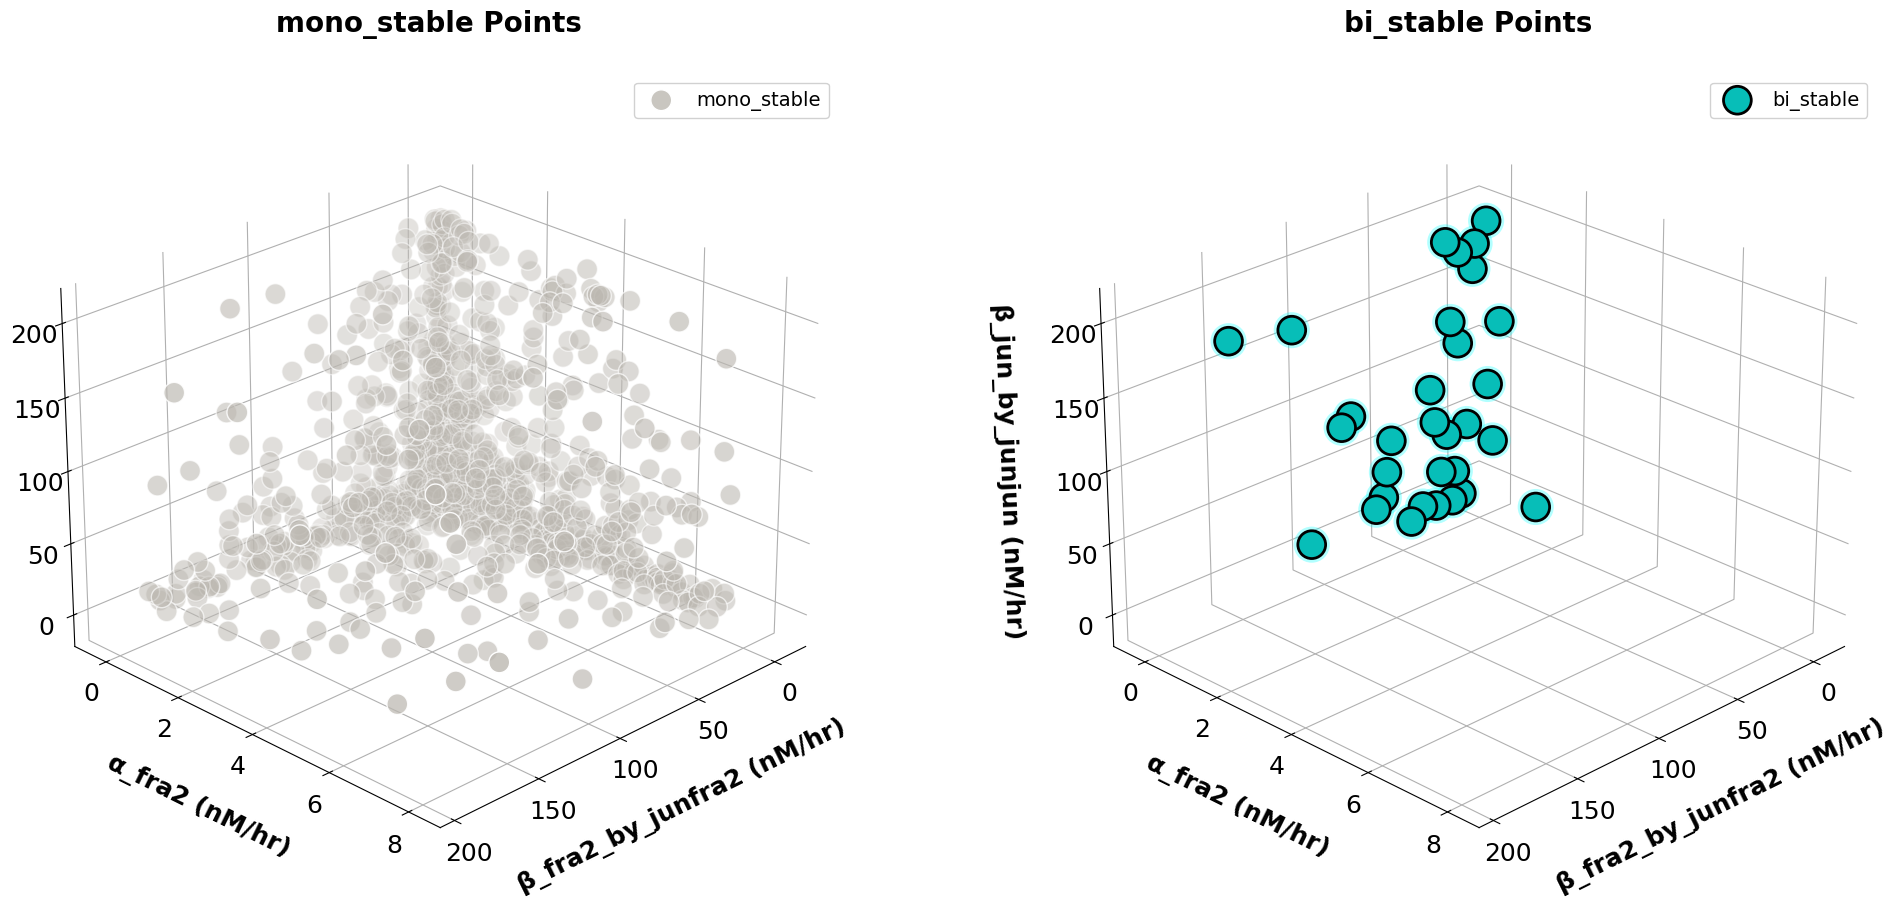

In [ ]:
# Plot
fig, ax = plot_3d_scatter_subplots(
    renamed_df, 
    'β_FRA2_by_JUNFRA2','α_FRA2','β_cJUN_by_cJUNcJUN',
    color_map={'bi_stable': '#07BEB8','mono_stable': '#BCB8B1'},
    opacity_map={'bi_stable': 1.0,'mono_stable': 0.8},
    size_map={'bi_stable': 20,'mono_stable': 15},
    edge_color_map={'bi_stable': 'black','mono_stable': 'white'},
    output_filename=f'multistable_{cell}_3d_scatter_fra2.pdf'
)

In [24]:
# print the columns of renamed_df
print(renamed_df.columns)

Index(['α_cFOS', 'α_cJUN', 'α_FRA1', 'α_FRA2', 'α_JUND', 'β_cJUN_by_cJUNcJUN',
       'β_cJUN_by_cJUNcFOS', 'β_FRA1_by_cJUNFRA1', 'β_FRA1_by_JUNDcFOS',
       'β_FRA2_by_cJUNFRA2', 'γ_cFOS', 'γ_cJUN', 'γ_FRA1', 'γ_FRA2', 'γ_JUND',
       'interest_class'],
      dtype='object')


In [12]:
# add a column that is the ratio of β_fra2_by_junfra2 and α_fra2
renamed_df['β_fra2_by_junfra2/α_fra2'] = renamed_df['β_fra2_by_junfra2'] / renamed_df['α_fra2']


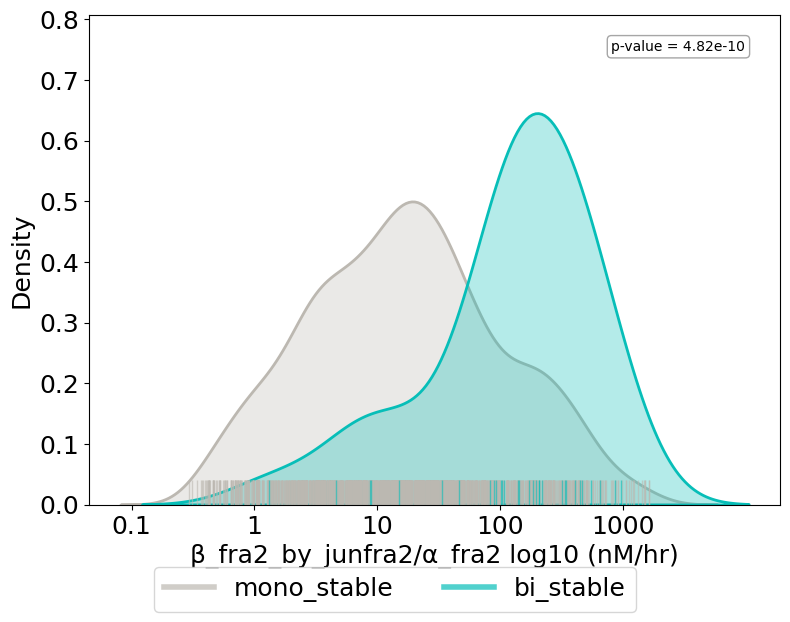

In [16]:
par_names = ['β_fra2_by_junfra2/α_fra2']
fig = plot_ap1.plot_parameter_distributions(renamed_df, par_names, 'interest_class', 
                                      color_palette={'mono_stable': '#BCB8B1', 'bi_stable': '#07BEB8'}, 
                                      ncols=1, figsize=(8, 6), stat_test='ks_test',
                                     output_filename=f'multistable_{cell}_fra2_ratio_distribution.pdf')

In [ ]:
# fig = plot_ap1.plot_2d_scatter(
#     data=renamed_df, 
#     x_param='α_fra2', 
#     y_param='β_fra2_by_junfra2',
#     class_column='interest_class',  # This specifies which column contains the classes
#     class_labels=['mono_stable', 'bi_stable'],           # This specifies the actual class labels
#     colors=['#BCB8B1', '#07BEB8'],
#     markers=['o', 'o'],
#     alpha_values=[0.3, 1],
#     figsize=(10, 6),
#     sizes=[50, 150],
#     ylim=[1.5,200],
#     xlim=[0,10],
#     log_scale=True,
#     edgecolors=['k', 'k'],
#     output_filename=f'multistable_{cell}_2d_scatter_fra2.pdf'
   
# )

#### Figure 5C Plot mono and bi stable with high or low outcomes

In [32]:
dat2 = dat.copy()
cols_to_remove = ['fos', 'jun', 'fra1', 'fra2', 'jund',]
dat2.drop(cols_to_remove, axis=1, inplace=True)

# drop duplicate based on param_index, init_cond_index, unique_steady_states,fos_ss,jun_ss,fra1_ss,fra2_ss,jund_ss
dat2.drop_duplicates(subset=['param_index','unique_steady_states','state'], inplace=True)

# keep the columns (basal_fra2).v, (fra2_by_junfra2).beta, unique_steady_states,fra2_ss
dat2 = dat2[['param_index', '(basal_fra2).v', '(fra2_by_junfra2).beta', 'unique_steady_states', 'fra2_ss']]

#if fra2_ss > 10 high else low
dat2['fra2_ss'] = np.where(dat2['fra2_ss'] > 10, 'high', 'low')
# rename fra2_ss to FRA2 steady state
dat2.rename(columns={'fra2_ss': 'FRA2 steady state'}, inplace=True)
# rename
renamed_df = rename_columns(dat2)
# Create log10 transformed columns
renamed_df['log10_α_FRA2'] = np.log10(renamed_df['α_FRA2'])
renamed_df['log10_β_FRA2_by_cJUNFRA2'] = np.log10(renamed_df['β_FRA2_by_cJUNFRA2'])



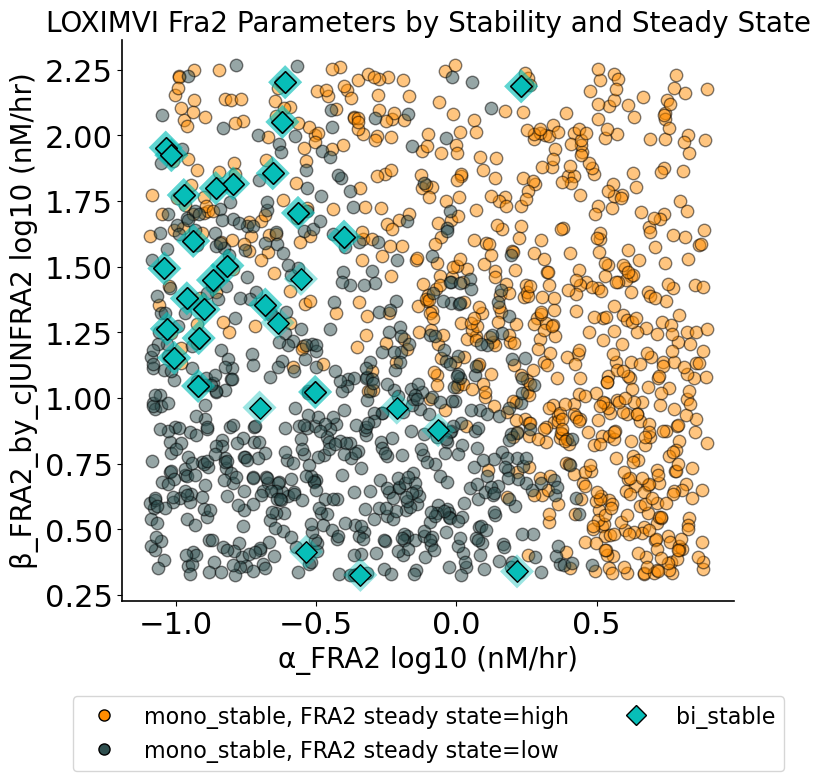

In [35]:
# Create figure 
plt.figure(figsize=(8, 8))

# Define markers and colors
markers = {'mono_stable': 'o', 'bi_stable': 'D'} 
colors = {'high': 'darkorange', 'low': 'darkslategray', 'bi_stable': '#07BEB8'}
sizes = {'mono_stable': 80, 'bi_stable': 120}  # Larger size for bistable points

# Plot mono_stable points
for fra2_state in ['high', 'low']:
    mask = (renamed_df['unique_steady_states'] == 'mono_stable') & (renamed_df['FRA2 steady state'] == fra2_state)
    subset = renamed_df[mask]
    
    plt.scatter(
        subset['log10_α_FRA2'], 
        subset['log10_β_FRA2_by_cJUNFRA2'],
        marker=markers['mono_stable'],
        c=colors[fra2_state],
        s=sizes['mono_stable'],
        edgecolors='black',
        alpha=0.5,
        label=f"mono_stable, FRA2 steady state={fra2_state}"
    )

# Plot all bi_stable points with glow effect
mask_bi = renamed_df['unique_steady_states'] == 'bi_stable'
bi_subset = renamed_df[mask_bi]

# First plot the glow
plt.scatter(
    bi_subset['log10_α_FRA2'], 
    bi_subset['log10_β_FRA2_by_cJUNFRA2'],
    marker=markers['bi_stable'],
    c='#07BEB8',  # Lighter skyblue for glow
    s=sizes['bi_stable'] * 2.5,  # Much larger for the glow
    alpha=0.4,  # Translucent for the glow effect
    edgecolors='none'  # No edge for the glow
)

# Then plot the actual points on top
plt.scatter(
    bi_subset['log10_α_FRA2'], 
    bi_subset['log10_β_FRA2_by_cJUNFRA2'],
    marker=markers['bi_stable'],
    c=colors['bi_stable'],
    s=sizes['bi_stable'],
    edgecolors='black',
    alpha=1,  # Higher alpha for the actual points
    label="bi_stable"
)

# Add labels and legend
plt.xlabel('α_FRA2 log10 (nM/hr)')
plt.ylabel('β_FRA2_by_cJUNFRA2 log10 (nM/hr)')
plt.title('LOXIMVI Fra2 Parameters by Stability and Steady State')
#plt.grid(True, alpha=0.3)

# Create a legend with custom handles
from matplotlib.lines import Line2D
custom_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markeredgecolor='black', markersize=8, label='mono_stable, FRA2 steady state=high'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkslategray', markeredgecolor='black', markersize=8, label='mono_stable, FRA2 steady state=low'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#07BEB8', markeredgecolor='black', markersize=10, label='bi_stable')
]

# Place legend at bottom
plt.legend(handles=custom_handles, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)

# Adjust layout to prevent legend cutoff
plt.tight_layout()
# save as pdf
plt.savefig(f'multistable_LOXIMVI_analysis_alpha_beta_fra2.pdf', dpi=300)
plt.show()

### Figure 4 Heterogeneity analysis for monostable states
#### Question: What features in our parameter space separate the diffrences you observe within the monostable states?

In [34]:
# subset only mono_stable
mono_stable = dat[dat['unique_steady_states'] == 'mono_stable'].copy()
# drop init_cond_index column
mono_stable.drop('init_cond_index', axis=1, inplace=True)

# drop duplicate param_index
mono_stable.drop_duplicates(subset='param_index', inplace=True)

# drop param_index
mono_stable.drop('param_index', axis=1, inplace=True)
# drop unique_steady_states
mono_stable.drop('unique_steady_states', axis=1, inplace=True)
# remove the columns fos, jun, fra1, fra2, jund
mono_stable.drop(['fos', 'jun', 'fra1', 'fra2', 'jund','fos_ss','jun_ss','fra1_ss','fra2_ss','jund_ss'], axis=1, inplace=True)


In [45]:
dat

,param_index,init_cond_index,(basal_fos).v,(basal_jun).v,(basal_fra1).v,(basal_fra2).v,(basal_jund).v,(jun_by_junjun).beta,(jun_by_junfos).beta,(fra1_by_junfra1).beta,...,fra1,fra2,jund,unique_steady_states,state,fos_ss,jun_ss,fra1_ss,fra2_ss,jund_ss
0,2,100,26.95602,0.50804,0.20539,0.44878,5.35435,23.87186,34.50234,3.95846,...,45.47052,4.39770,54.80465,mono_stable,"high,low,high,low,high",46.7,1.0,107.5,1.9,17.8
1,2,95,26.95602,0.50804,0.20539,0.44878,5.35435,23.87186,34.50234,3.95846,...,33.56343,1.67222,29.72116,mono_stable,"high,low,high,low,high",46.7,1.0,107.5,1.9,17.8
2,2,96,26.95602,0.50804,0.20539,0.44878,5.35435,23.87186,34.50234,3.95846,...,1.60746,2.30712,44.38918,mono_stable,"high,low,high,low,high",46.7,1.0,107.5,1.9,17.8
3,2,97,26.95602,0.50804,0.20539,0.44878,5.35435,23.87186,34.50234,3.95846,...,25.50349,0.49166,77.45921,mono_stable,"high,low,high,low,high",46.7,1.0,107.5,1.9,17.8
4,2,98,26.95602,0.50804,0.20539,0.44878,5.35435,23.87186,34.50234,3.95846,...,12.45746,3.62302,14.90250,mono_stable,"high,low,high,low,high",46.7,1.0,107.5,1.9,17.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2272947,39997,50,55.57384,0.11293,3.22576,0.54404,4.82604,131.69051,13.12777,9.45439,...,1.55621,0.62167,72.04387,mono_stable,"high,low,high,low,high",60.5,0.2,16.6,3.9,11.9
2272948,39997,51,55.57384,0.11293,3.22576,0.54404,4.82604,131.69051,13.12777,9.45439,...,19.67332,4.24453,119.80382,mono_stable,"high,low,high,low,high",60.5,0.2,16.6,3.9,11.9
2272949,39997,52,55.57384,0.11293,3.22576,0.54404,4.82604,131.69051,13.12777,9.45439,...,1.98982,0.74114,128.18160,mono_stable,"high,low,high,low,high",60.5,0.2,16.6,3.9,11.9
2272950,39997,53,55.57384,0.11293,3.22576,0.54404,4.82604,131.69051,13.12777,9.45439,...,2.39569,1.44661,17.40560,mono_stable,"high,low,high,low,high",60.5,0.2,16.6,3.9,11.9


In [47]:
# High FRA2 state should be class 1 for LOXIMVI
# High cFOS state should be class 1 for COLO858
# High FRA2 state should be class 1 for WM902B
interest_states = ['high,low,high,low,high']

mono_stable['interest_class'] = np.where(mono_stable['state'].isin(interest_states), 1, 0)

final_df = mono_stable.drop(columns = ['state'])

In [48]:
renamed_df = rename_columns(final_df.copy())

In [49]:
renamed_df


,α_cFOS,α_cJUN,α_FRA1,α_FRA2,α_JUND,β_cJUN_by_cJUNcJUN,β_cJUN_by_cJUNcFOS,β_FRA1_by_cJUNFRA1,β_FRA1_by_JUNDcFOS,β_FRA2_by_cJUNFRA2,γ_cFOS,γ_cJUN,γ_FRA1,γ_FRA2,γ_JUND,interest_class
0,26.95602,0.50804,0.20539,0.44878,5.35435,23.87186,34.50234,3.95846,72.93446,87.29735,0.58739,0.56338,0.17690,0.25257,0.11311,1
150,7.15974,0.31774,0.16072,0.54048,4.26423,7.73887,4.17399,40.56476,60.97516,194.28917,0.48413,0.64775,0.38418,0.20111,0.19423,1
300,11.66137,0.42260,3.70721,0.32775,7.53577,4.41122,3.80039,2.26229,12.82114,142.24331,1.05475,0.67627,0.51045,0.28630,0.12478,1
450,15.55048,4.99971,0.70757,1.00437,5.11122,155.07185,3.10791,5.45237,17.34999,4.04609,0.58534,0.85336,0.19216,0.09107,0.15842,1
600,15.70035,0.32285,2.32457,1.63723,4.31938,65.28138,22.53381,96.63559,58.03772,15.20315,0.46253,0.52475,0.54096,0.19259,0.10401,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2272202,20.20837,1.05627,0.71343,1.80778,5.45404,7.38354,9.19275,12.23017,5.85757,4.12324,0.81596,1.19400,0.28715,0.27680,0.08184,1
2272352,23.96882,1.76506,0.74736,2.06455,4.36644,11.96480,14.74865,185.84459,16.90029,2.84839,1.02358,1.03512,0.47817,0.25328,0.12539,1
2272502,5.84196,1.84934,0.47798,0.15982,5.77825,23.12290,2.67421,73.05457,10.75602,84.12244,0.62978,1.04436,0.27691,0.12974,0.11386,1
2272652,13.28676,4.62386,0.30056,0.68081,4.42421,127.97453,4.18890,103.41326,8.96498,7.69569,0.59073,0.86583,0.55963,0.31349,0.11352,1


/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ap1_proj/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: 

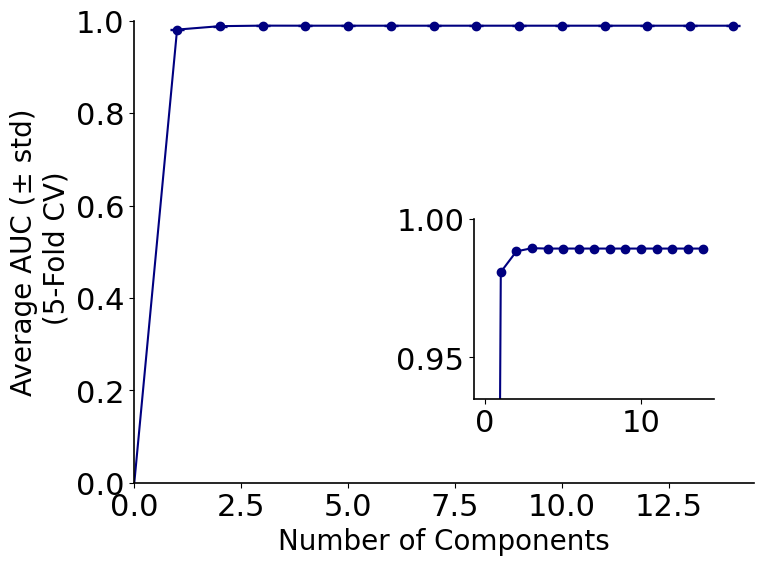

Maximum AUC at components: 3
Diminishing returns at components: 1
Maximum mean AUC: 0.989 ± 0.001
AUC at diminishing returns: 0.981 ± 0.002
Recommended number of components: 1
Optimal number of components: 1
Component 1:
Cumulative Y variance: 50.91%
Incremental Y variance: 50.91%


In [52]:
X = renamed_df.drop(columns = ['interest_class'])
y = renamed_df['interest_class']

# keep one hot encoding as False
plsda = PLSDA(n_components=None, cv_folds=5, one_hot_encode=False, downsample_ratio= 3)

# Determine the optimal number of components
optimal_components, mean_scores = plsda.find_optimal_components(X, y, max_components=14,save_plot=False)
print(f'Optimal number of components: {optimal_components}')

# Fit and transform the data using the optimal number of components
plsda.n_components = 1
X_pls, x_var,y_var, y_encoded, X_downsampled, y_balanced = plsda.fit_transform(X, y)

class_descriptions = {0: 'FRA1 low', 1: 'FRA1 high'}
# plot_scores = plsda.plot_scores_with_density(X_pls, x_var,y_var, y_encoded, lv1 = 0, lv2 = 1, class_descriptions=class_descriptions, 
#                                              colors = ['darkslategrey','darkorange'],
#                   alpha_values = [0.5, 0.9],line_colors = ['w','k'], save_plot=True)


In [ ]:
# y_scores, y_encoded = plsda.cross_validation(X, y)
# #plsda.plot_roc(y_scores, y_encoded)
# plsda.plot_mean_roc(X, y, save_plot=False)



In [ ]:
# vip_scores = plsda.compute_vip()
# signed_vip_scores, feature_names = plsda.compute_signed_vip(X,y,X.columns)
# # save figure as pdf

# plsda.plot_signed_vip(signed_vip_scores, feature_names, save_plot=True, colors=['darkslategrey','darkorange'])


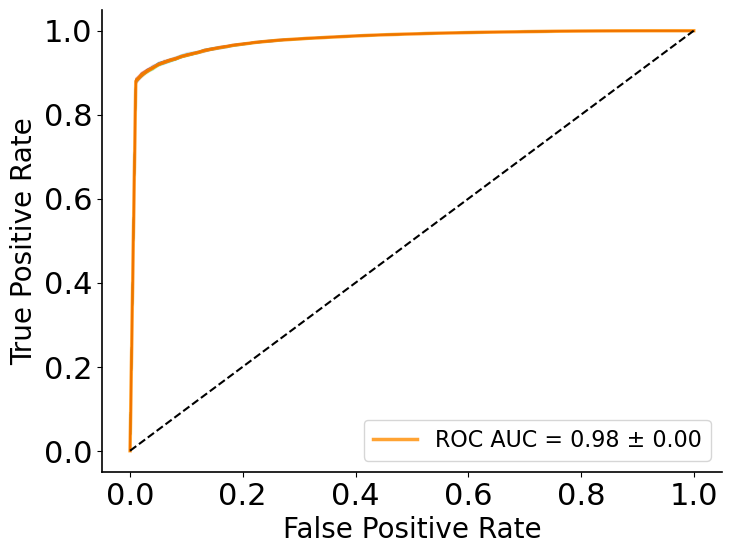

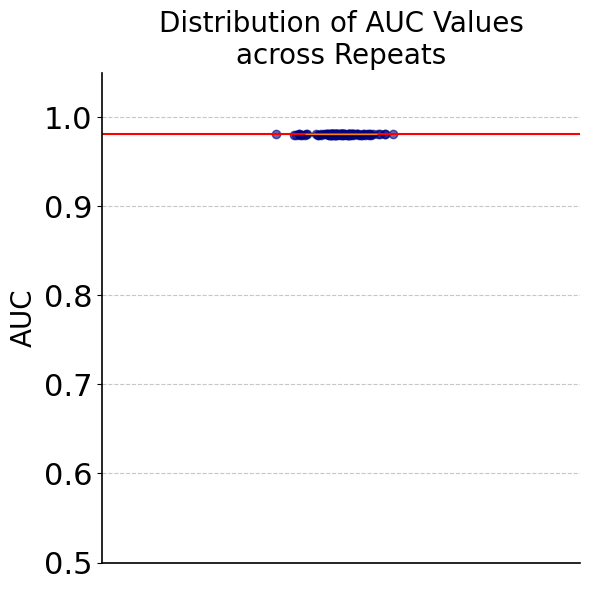

Repeated CV Results (100 repeats):
Mean AUC: 0.981 ± 0.000
Range: [0.980, 0.982]
Repeated cross-validation AUC: 0.981 ± 0.000


In [ ]:
mean_auc, std_auc = plsda.repeated_cv_with_visualization(
    X, y, n_repeats=1000, save_plot=True, show_individual_curves=True
)
print(f"Repeated cross-validation AUC: {mean_auc:.3f} ± {std_auc:.3f}")

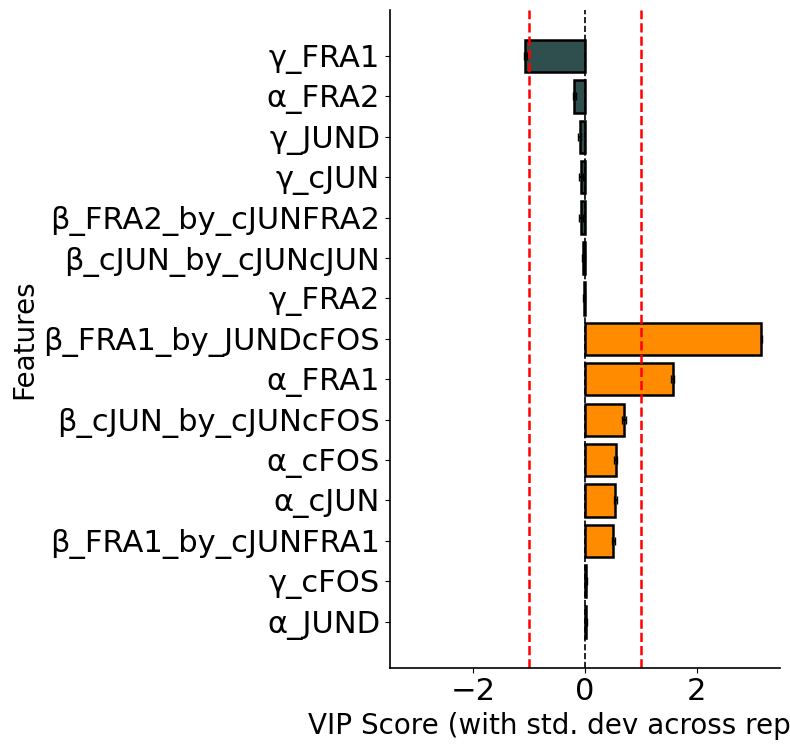

In [ ]:
mean_vips, std_vips, feature_names = plsda.plot_repeated_vip(
    X, y, n_repeats=1000, save_plot=True
)

#### Exploaratory analysis

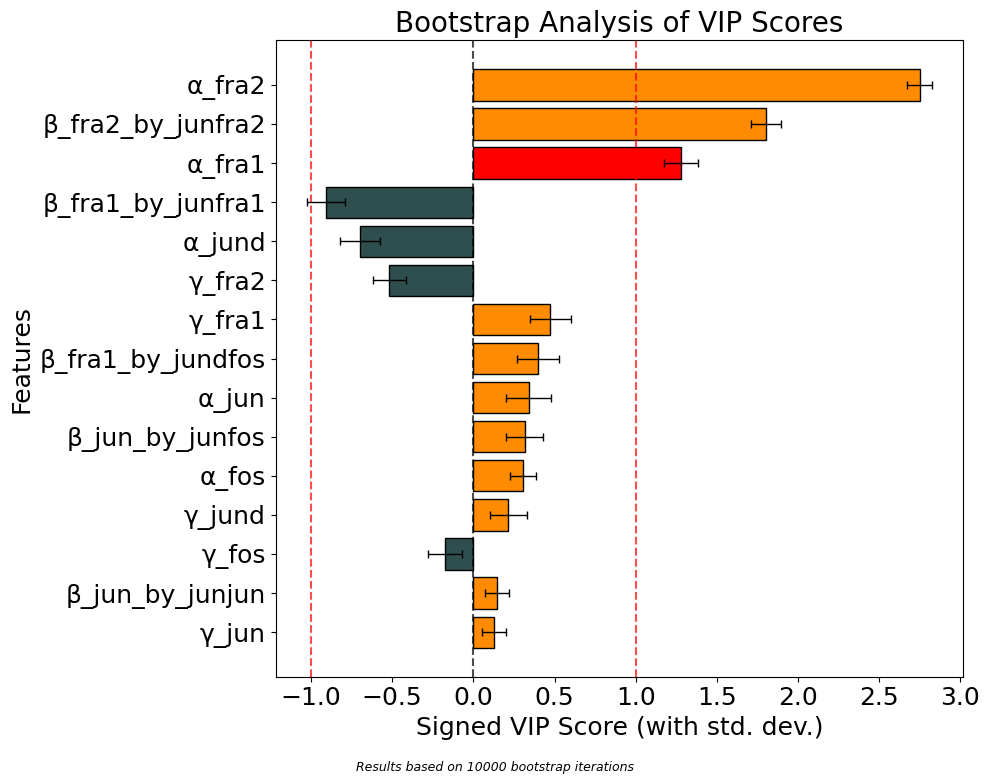

,Feature,Mean VIP,Std Dev,Sign,VIP >= 1 (%),Bootstrap Ratio
0,γ_jun,0.127635,0.076068,1.000000,0.000000,1.677921
1,β_jun_by_junjun,0.146379,0.073746,1.000000,0.000000,1.984908
2,γ_fos,0.176386,0.103531,-1.000000,0.000000,1.703712
3,γ_jund,0.213558,0.113574,1.000000,0.000000,1.880350
4,α_fos,0.305067,0.080573,1.000000,0.000000,3.786198
5,β_jun_by_junfos,0.316272,0.113075,1.000000,0.000000,2.797019
6,α_jun,0.340609,0.136882,1.000000,0.000000,2.488342
7,β_fra1_by_jundfos,0.398955,0.128862,1.000000,0.000000,3.095986
8,γ_fra1,0.474344,0.124724,1.000000,0.000000,3.803138
9,γ_fra2,0.517204,0.100603,-1.000000,0.000000,5.141026


,Feature,Mean VIP,Std Dev,Sign,VIP >= 1 (%),Bootstrap Ratio
0,γ_jun,0.127635,0.076068,1.000000,0.000000,1.677921
1,β_jun_by_junjun,0.146379,0.073746,1.000000,0.000000,1.984908
2,γ_fos,0.176386,0.103531,-1.000000,0.000000,1.703712
3,γ_jund,0.213558,0.113574,1.000000,0.000000,1.880350
4,α_fos,0.305067,0.080573,1.000000,0.000000,3.786198
5,β_jun_by_junfos,0.316272,0.113075,1.000000,0.000000,2.797019
6,α_jun,0.340609,0.136882,1.000000,0.000000,2.488342
7,β_fra1_by_jundfos,0.398955,0.128862,1.000000,0.000000,3.095986
8,γ_fra1,0.474344,0.124724,1.000000,0.000000,3.803138
9,γ_fra2,0.517204,0.100603,-1.000000,0.000000,5.141026


In [14]:
# Now run the bootstrap analysis
# Set number of bootstraps (more = better but slower)
n_bootstraps = 10000

# Run bootstrap analysis
bootstrap_results = plsda.bootstrap_vip_analysis(X, y, n_bootstraps=n_bootstraps, random_seed=42)

# Plot the results with your feature of interest highlighted
plsda.plot_bootstrap_vip(bootstrap_results, focus_feature='α_fra1', 
                        colors=['darkslategray', 'darkorange'], 
                        sort_by='absolute', save_plot=True)

In [16]:
renamed_df['interest_class'] = renamed_df['interest_class'].map({1: 'FRA2 high', 0: 'FRA2 low'})
renamed_df

,α_fos,α_jun,α_fra1,α_fra2,α_jund,β_jun_by_junjun,β_jun_by_junfos,β_fra1_by_junfra1,β_fra1_by_jundfos,β_fra2_by_junfra2,γ_fos,γ_jun,γ_fra1,γ_fra2,γ_jund,interest_class
0,3.51348,6.23938,2.75645,1.17920,5.03680,20.58021,5.81476,78.26636,21.73407,17.17804,0.53332,0.73908,0.30491,0.10016,0.08571,FRA2 high
150,4.83183,5.65293,0.17113,2.54778,7.01086,58.12772,31.97274,37.20289,102.96200,35.56151,1.53200,0.49401,0.31378,0.11460,0.13307,FRA2 high
300,0.69610,7.51703,0.17390,0.66903,2.47411,8.79305,169.28631,20.96384,143.84768,2.97708,0.91342,0.76951,0.33246,0.08788,0.06786,FRA2 low
450,0.72296,6.10969,2.91160,1.25732,5.29329,28.86403,37.24679,53.37406,20.63374,32.33980,0.51991,0.52255,0.54039,0.12717,0.14071,FRA2 high
600,8.60226,6.19385,0.17837,0.44547,4.28368,3.06599,4.38193,121.09712,47.92727,6.25562,0.93905,0.57594,0.54014,0.09317,0.07512,FRA2 low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192737,2.37300,6.35660,0.17751,1.83279,2.32691,192.29424,3.42321,128.57895,110.00358,26.59985,0.77317,1.15439,0.46146,0.20406,0.11004,FRA2 high
192887,1.18747,7.88670,0.14613,0.36399,4.30143,18.62674,102.69864,73.89681,2.36649,42.23103,0.78702,0.85766,0.30010,0.11151,0.16108,FRA2 low
192937,1.02638,6.21016,3.21132,2.35344,6.45143,67.53010,3.29546,32.27748,77.10979,44.00157,1.02830,1.11156,0.31652,0.11765,0.13490,FRA2 high
193087,7.29294,0.14510,0.14453,1.54536,7.27952,21.59967,139.56446,10.31931,66.98887,4.13817,0.84657,0.54762,0.68252,0.30267,0.10912,FRA2 low


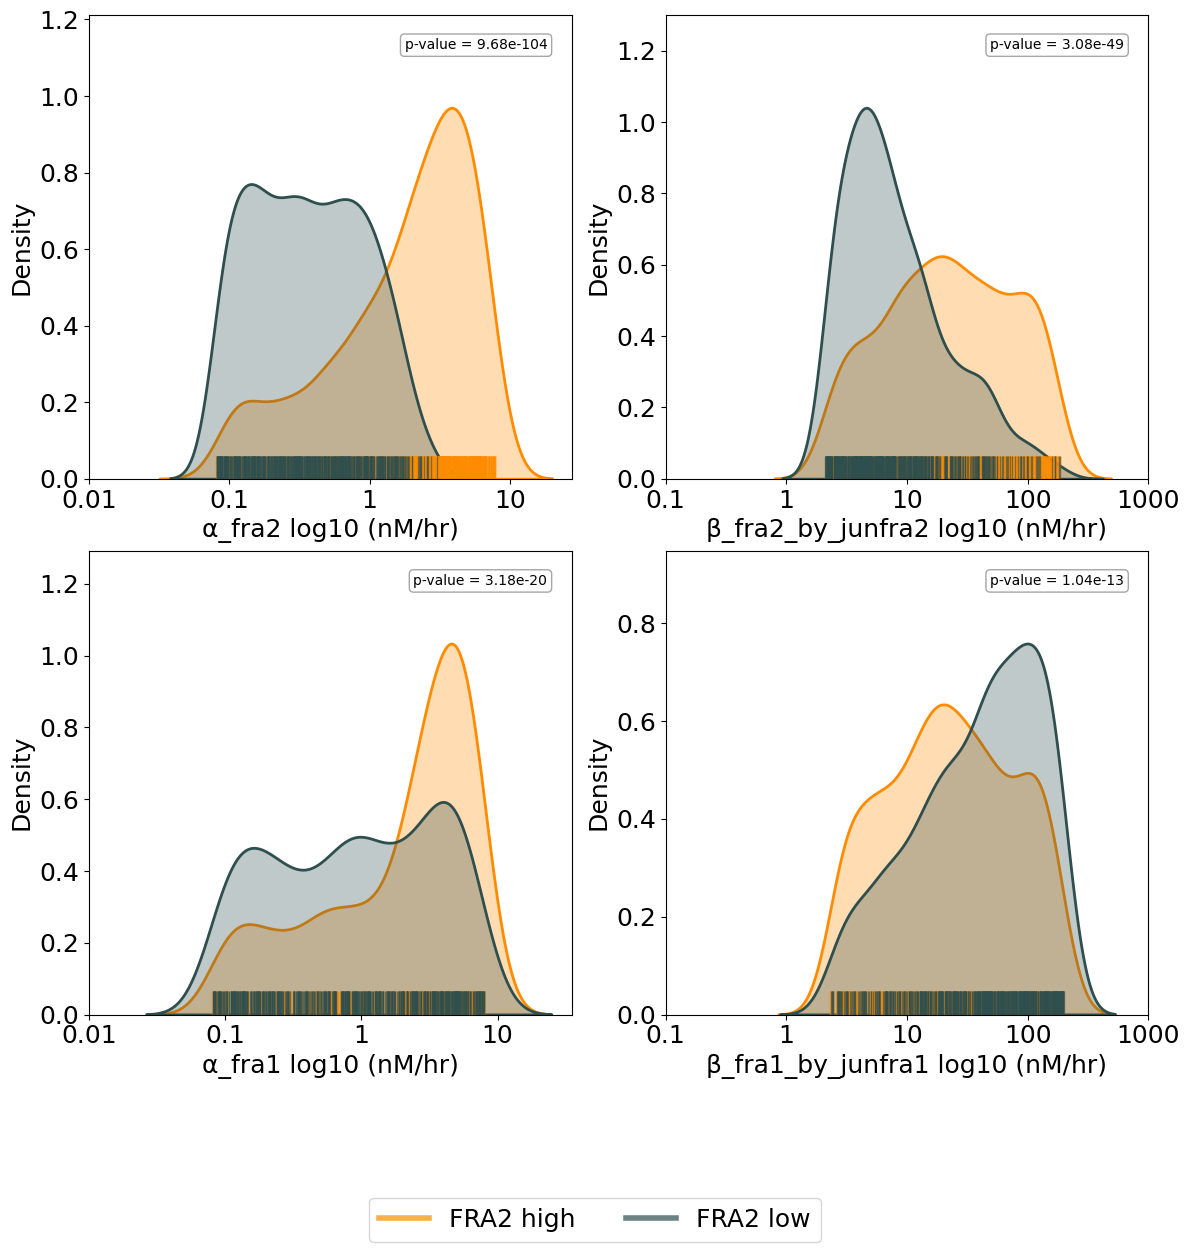

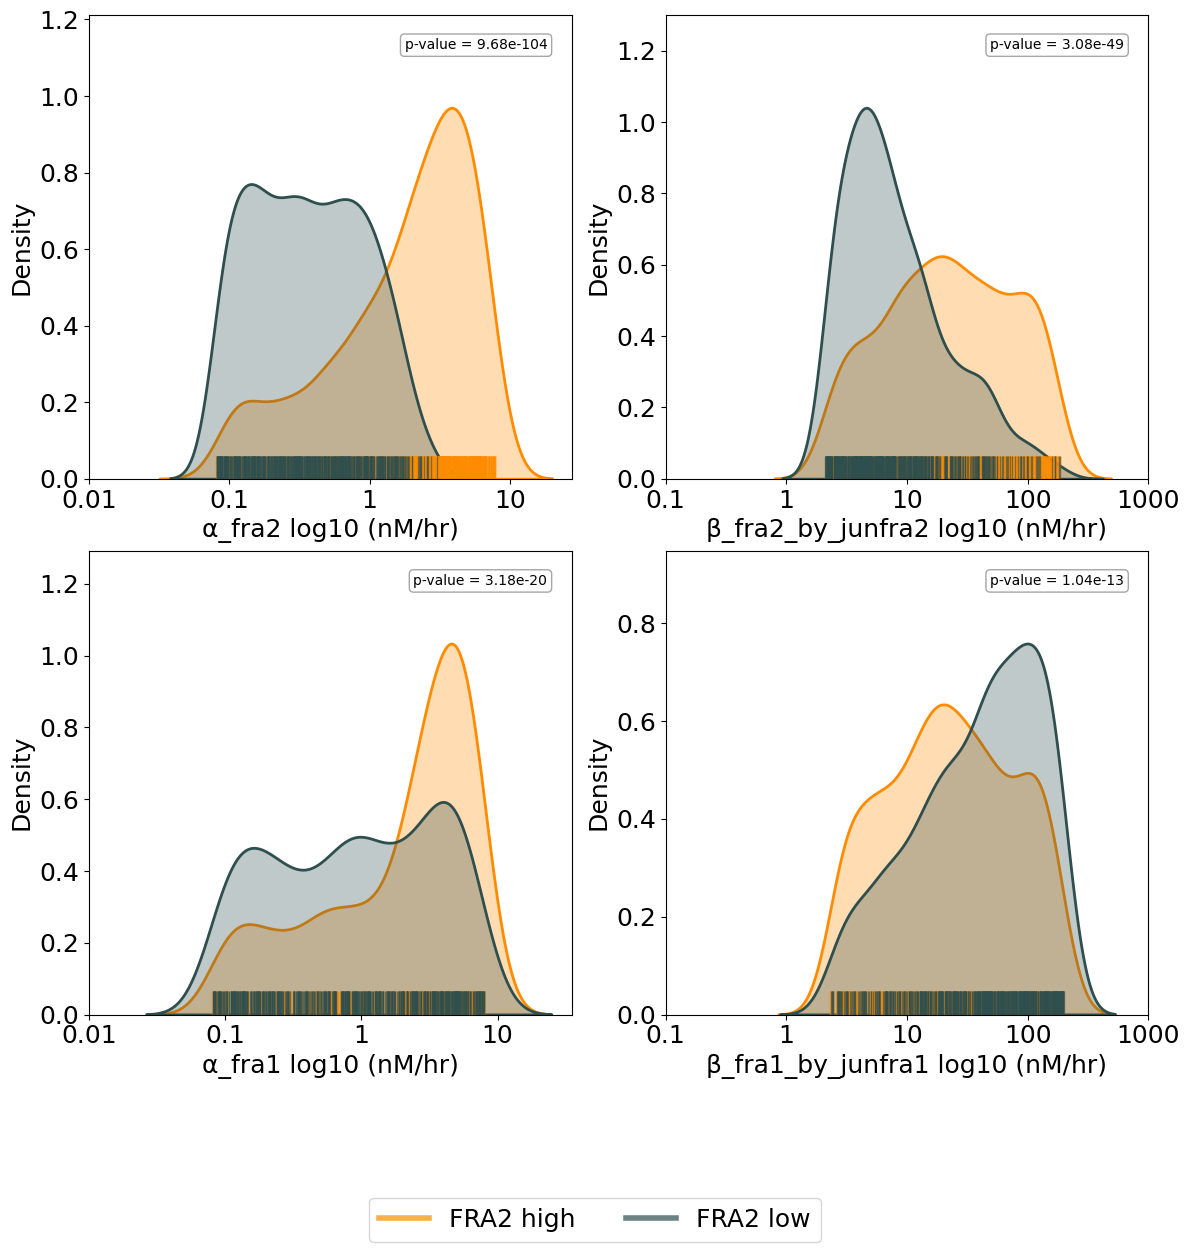

In [89]:
# plot distribution of fra2 for the high and low fra2 states

par_names = ['α_fra2', 'β_fra2_by_junfra2', 'α_fra1','β_fra1_by_junfra1']
plot_ap1.plot_parameter_distributions(renamed_df, par_names, 'interest_class', 
                                      color_palette={'FRA2 low': 'darkslategrey', 'FRA2 high': 'darkorange'}, 
                                      ncols=2, figsize=(12,12), stat_test='mann_whitney',
                                     output_filename=f'monostable_{cell}_distribution.pdf')

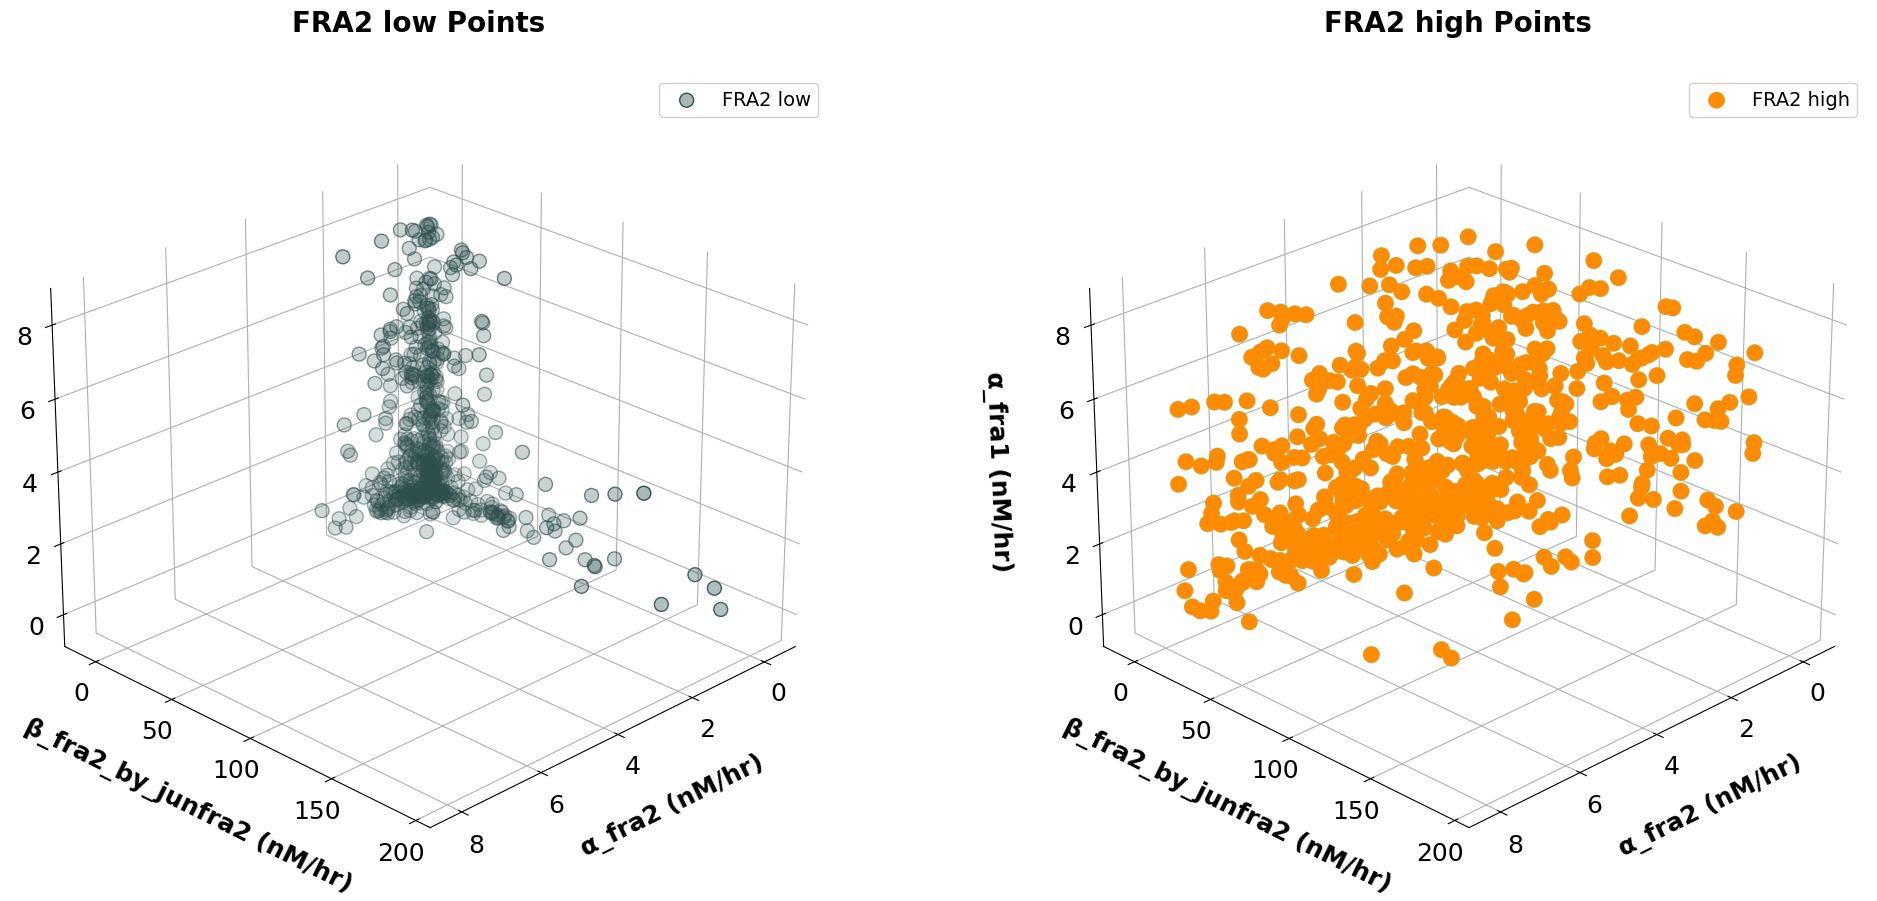

In [43]:
fig, ax = plot_3d_scatter_subplots(
    renamed_df, 
    'α_fra2','β_fra2_by_junfra2','α_fra1',
    class0='FRA2 low',
    class1='FRA2 high',
    color_map={'FRA2 low': 'darkslategrey', 'FRA2 high': 'darkorange'},
    opacity_map={'FRA2 low': 0.4, 'FRA2 high': 1.0},
    size_map={'FRA2 low': 10, 'FRA2 high': 10},
    edge_color_map={'FRA2 low': 'darkslategrey','FRA2 high': 'darkorange'},
    output_filename=f'monostable_{cell}_3d_scatter_FRA2.pdf'
)